# Gemaakt door Jens Hooijmans & Ivar Hekkink

De **MLSP 2013 Bird Classification Challenge** draait om het automatisch herkennen van vogelsoorten in 10-seconden audio-opnames die in echte natuurcondities zijn gemaakt. Elke opname kan meerdere vogelsoorten bevatten (multi-label classificatie) en bevat vaak achtergrondgeluiden zoals wind, regen en insecten. De dataset bevat opnames uit een bosgebied met in totaal 19 vogelsoorten. De uitdaging is om de geluiden om te zetten in bruikbare kenmerken, bijvoorbeeld via spectrogrammen, en vervolgens een model te trainen dat voor elke soort voorspelt of die in de opname aanwezig is.


In [3]:
#%pip install librosa
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import random
from pathlib import Path


In [4]:

# --- Dynamische Pad Configuratie ---

# 1. Definieer de twee mogelijke paden
# Let op de r"..." voor het Windows-pad, dit is belangrijk voor de backslashes!
pad_crabbedfish = Path("/home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data/src_wavs")
pad_ivar = Path(r"C:\Users\Ivar\Desktop\Bird Data\mlsp-2013-birds\mlsp_contest_dataset\mlsp_contest_dataset\essential_data\src_wavs")

# 2. Controleer welk pad bestaat en stel 'data_map' in
if pad_crabbedfish.exists():
    data_map = pad_crabbedfish
    print("✅ Pad ingesteld voor: crabbedfish (Linux)")
elif pad_ivar.exists():
    data_map = pad_ivar
    print("✅ Pad ingesteld voor: Ivar (Windows)")
else:
    # Dit gebeurt als geen van beide paden wordt gevonden
    data_map = None
    print("❌ FOUT: Kon de data-map op geen van beide locaties vinden.")
    print(f"   Gezocht op (Linux): {pad_crabbedfish}")
    print(f"   Gezocht op (Windows): {pad_ivar}")

# --- Vanaf hier kun je de code gebruiken zoals voorheen ---

if data_map:
    print(f"\nWerken met map: {data_map}")
    
    # 3. Haal alle .wav-bestanden op uit de gevonden map
    wav_bestanden = list(data_map.glob("*.wav"))
    
    print(f"Aantal .wav bestanden gevonden: {len(wav_bestanden)}")
    
    # 4. Toon de eerste 5 bestanden als voorbeeld
    if wav_bestanden:
        print("\n--- Eerste 5 bestanden ---")
        for f in wav_bestanden[:5]:
            print(f.name)

✅ Pad ingesteld voor: crabbedfish (Linux)

Werken met map: /home/crabbedfish/Desktop/mlsp-2013-birds/mlsp_contest_dataset/mlsp_contest_dataset/essential_data/src_wavs
Aantal .wav bestanden gevonden: 645

--- Eerste 5 bestanden ---
PC8_20090705_050000_0030.wav
PC11_20100513_043000_0740.wav
PC15_20090513_070000_0030.wav
PC5_20090804_070000_0040.wav
PC16_20090705_070000_0040.wav


--- 15 willekeurige bestanden geselecteerd ---


/tmp/ipykernel_352196/1893103714.py:61: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


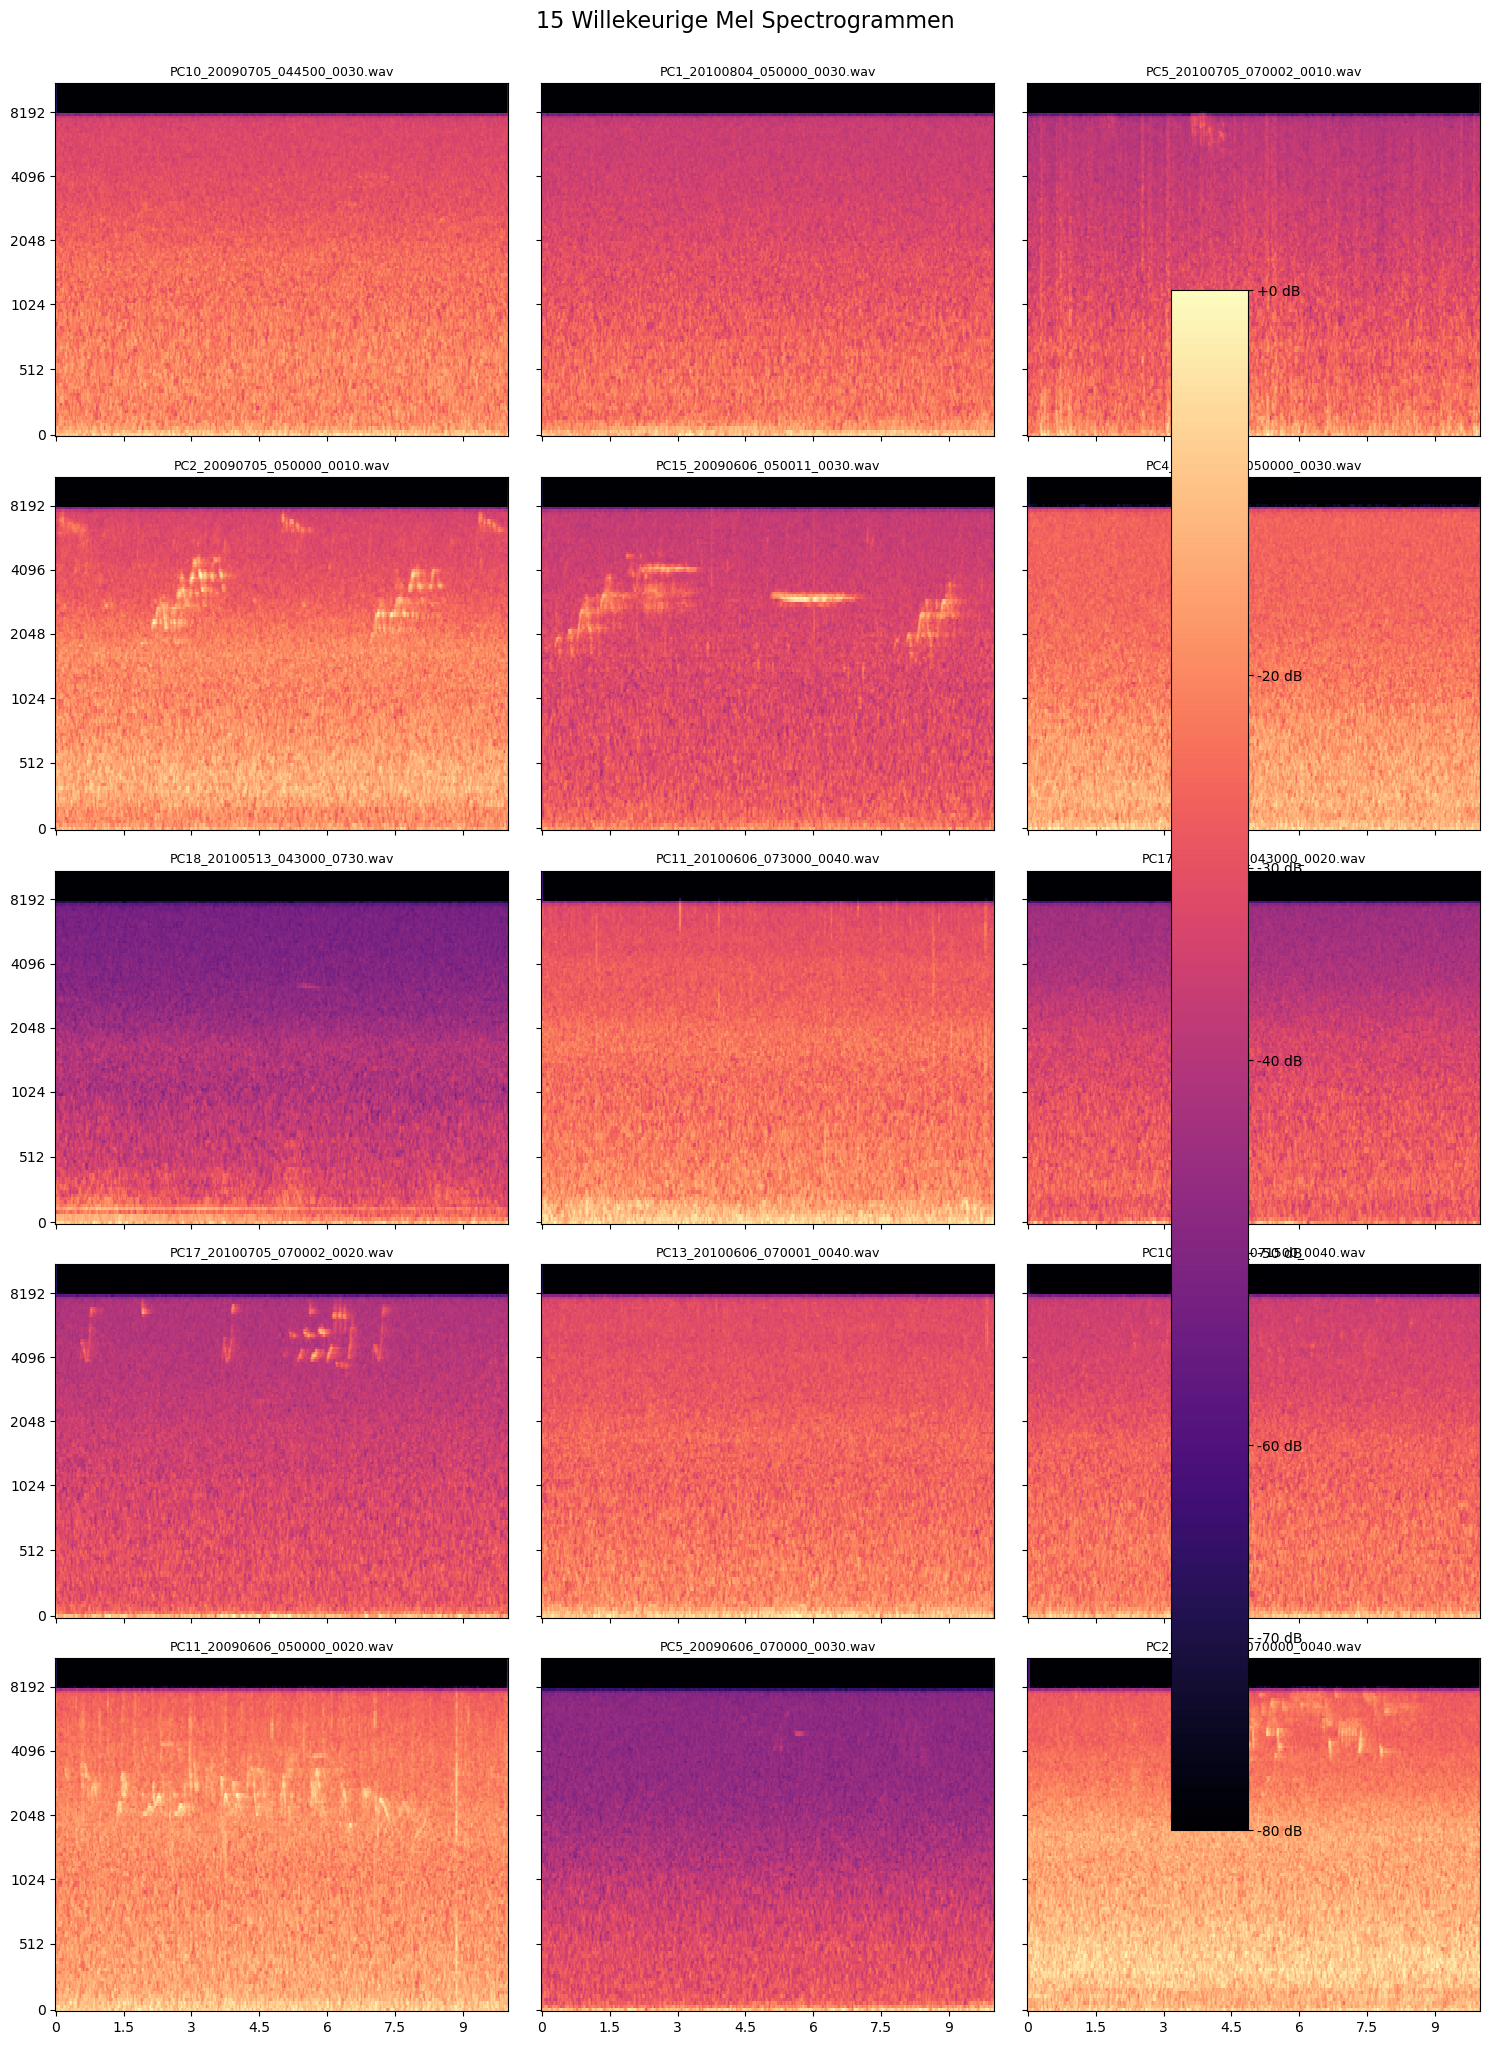

In [20]:

# Zorg dat 'wav_bestanden' bestaat uit de vorige cel
if 'wav_bestanden' not in locals() or not wav_bestanden:
    print("Run eerst de vorige cel om 'wav_bestanden' te vullen.")
else:
    # --- AANPASSING START ---
    
    # 1. Bepaal hoeveel we er willen
    AANTAL_PLOTS = 15
    
    # Zeker zijn dat we niet meer proberen te pakken dan er zijn
    if len(wav_bestanden) < AANTAL_PLOTS:
        print(f"Waarschuwing: Minder dan {AANTAL_PLOTS} bestanden beschikbaar. Pak ze allemaal.")
        aantal_te_kiezen = len(wav_bestanden)
    else:
        aantal_te_kiezen = AANTAL_PLOTS
        
    # 2. Kies 15 willekeurige bestanden uit de lijst
    gekozen_bestanden = random.sample(wav_bestanden, aantal_te_kiezen)
    
    print(f"--- {aantal_te_kiezen} willekeurige bestanden geselecteerd ---")

    # 3. Maak een subplot-grid aan (5 rijen, 3 kolommen)
    # figsize is (breedte, hoogte) in inches
    fig, axes = plt.subplots(5, 3, figsize=(15, 20), sharex=True, sharey=True)
    
    # 4. Loop door elk gekozen bestand en de bijbehorende 'as' (plot-locatie)
    # .flatten() maakt van de 5x3 grid een simpele lijst van 15
    for bestand, ax in zip(gekozen_bestanden, axes.flatten()):
        
        # --- Dit is dezelfde logica als voorheen, maar nu in een loop ---
        
        # A. Laad het audio-bestand
        SAMPLE_RATE = 22050 
        try:
            y, sr = librosa.load(bestand, sr=SAMPLE_RATE)

            # B. Maak het Mel Spectrogram
            S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
            S_db = librosa.power_to_db(S, ref=np.max)

            # C. Visualiseer op de specifieke 'ax'
            # We voegen 'ax=ax' toe om te vertellen waar te plotten
            img = librosa.display.specshow(S_db, sr=sr, x_axis='time', y_axis='mel', ax=ax)
            
            # Zet de (verkorte) bestandsnaam als titel voor de subplot
            ax.set_title(bestand.name, fontsize=9)
            ax.set_xlabel(None) # Verberg x-as label voor netheid
            ax.set_ylabel(None) # Verberg y-as label voor netheid
        
        except Exception as e:
            # Soms kan een audiobestand corrupt zijn, vang dit op
            print(f"Fout bij laden {bestand.name}: {e}")
            ax.set_title(f"Fout: {bestand.name}", fontsize=9, color='red')

    # --- AANPASSING EIND ---

    # Voeg een algemene colorbar toe voor de hele figuur
    fig.colorbar(img, ax=axes, format='%+2.0f dB')
    
    # Zorgt dat de titels en plots niet overlappen
    plt.tight_layout() 
    
    # Stel een overkoepelende titel in
    fig.suptitle(f'{aantal_te_kiezen} Willekeurige Mel Spectrogrammen', fontsize=16, y=1.02)
    
    # Toon de uiteindelijke grid met plots
    plt.show()